In [ ]:
import pandas as pd 
import numpy as np
# ! pip install seaborn # ist schon in der virtuellen Umgebung installiert, daher auskommentiert
import seaborn as sns
import scipy 

In [3]:
food = pd.read_csv('food.csv', index_col=0)
food.head()

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr.Veg
Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0


Preprocess data using z-transformation

Use StandardScaler from sklearn.preprocessing

In [ ]:
# preprocess data using StandardScaler from sklearn. preprocessing. 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
food_scaled = scaler.fit_transform(food)   

In [7]:
# apply KMeans clustering using KMeans from sklearn. cluster. 
from sklearn.cluster import KMeans
# vary k from 2 to 5
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k)

    # compute the silhouette coefficient using metrics.silhouette_score from sklearn. metrics.
    from sklearn import metrics
    silhouette_avg = metrics.silhouette_score(food_scaled, kmeans.fit_predict(food_scaled))
    print(f"For k={k}, the average silhouette score is: {silhouette_avg}")


# kmeans = KMeans(n_clusters=3)

For k=2, the average silhouette score is: 0.3036595713561536
For k=3, the average silhouette score is: 0.3351693984160507
For k=4, the average silhouette score is: 0.22912471223940334
For k=5, the average silhouette score is: 0.263945009757533


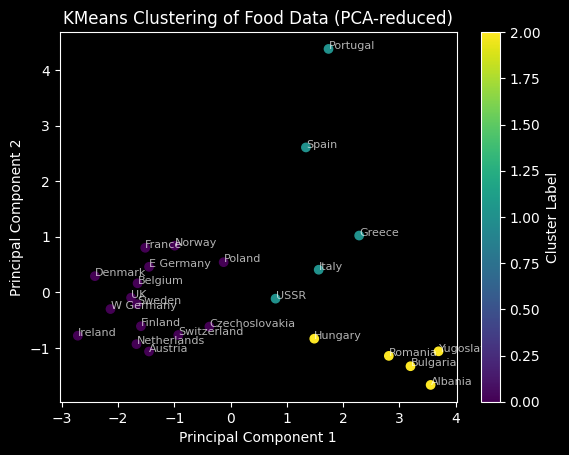

In [35]:
# Visualize final KMeans clustering using PCA, using PCA(n_components=2) from sklearn. decomposition. 
from sklearn.decomposition import PCA
# PCA reduziert auf den zweidimensionalen Raum für die Visualisierung 
pca = PCA(n_components=2)
food_pca = pca.fit_transform(food_scaled)

# fit KMeans with k=3
kmeans = KMeans(n_clusters=3)
kmeans.fit(food_pca)    

# visualize the clusters using matplotlib. pyplot. scatter from matplotlib. pyplot. 
import matplotlib.pyplot as plt
plt.scatter(food_pca[:, 0], food_pca[:, 1], c=kmeans.labels_, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KMeans Clustering of Food Data (PCA-reduced)')
plt.colorbar(label='Cluster Label')
# label points 
for i, country in enumerate(food.index):
    plt.annotate(country, (food_pca[i, 0], food_pca[i, 1]), fontsize=8, alpha=0.7)
plt.show()  

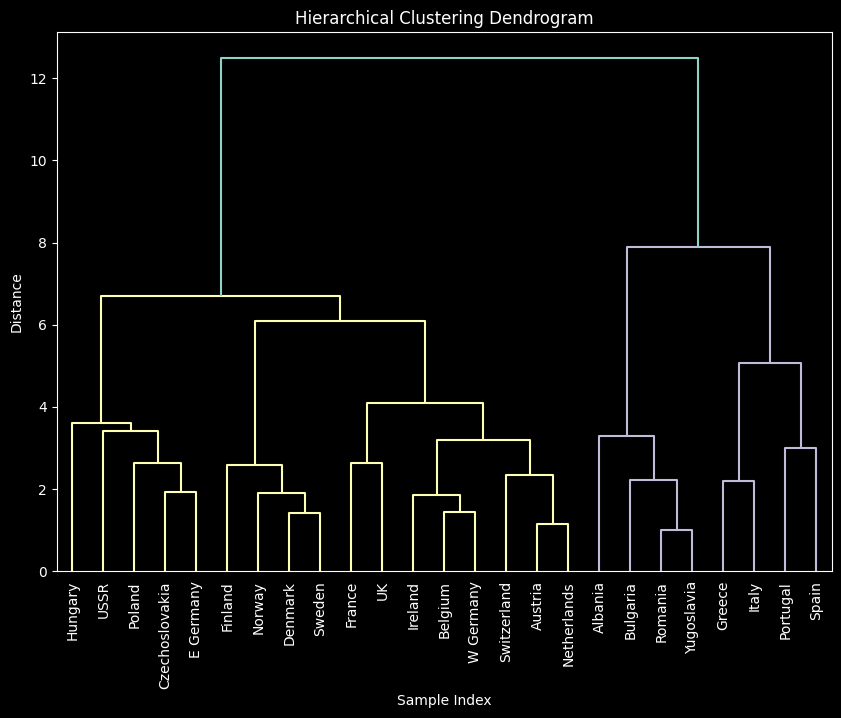

In [30]:
# perform hirarcical clustering using linkage() from scipy.cluster.hierarchy 
from scipy.cluster.hierarchy import linkage, dendrogram
# compute the linkage matrix using the 'ward' method
Z = linkage(food_scaled, method='ward')
# plot the dendrogram using dendrogram(). 
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=food.index, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()  

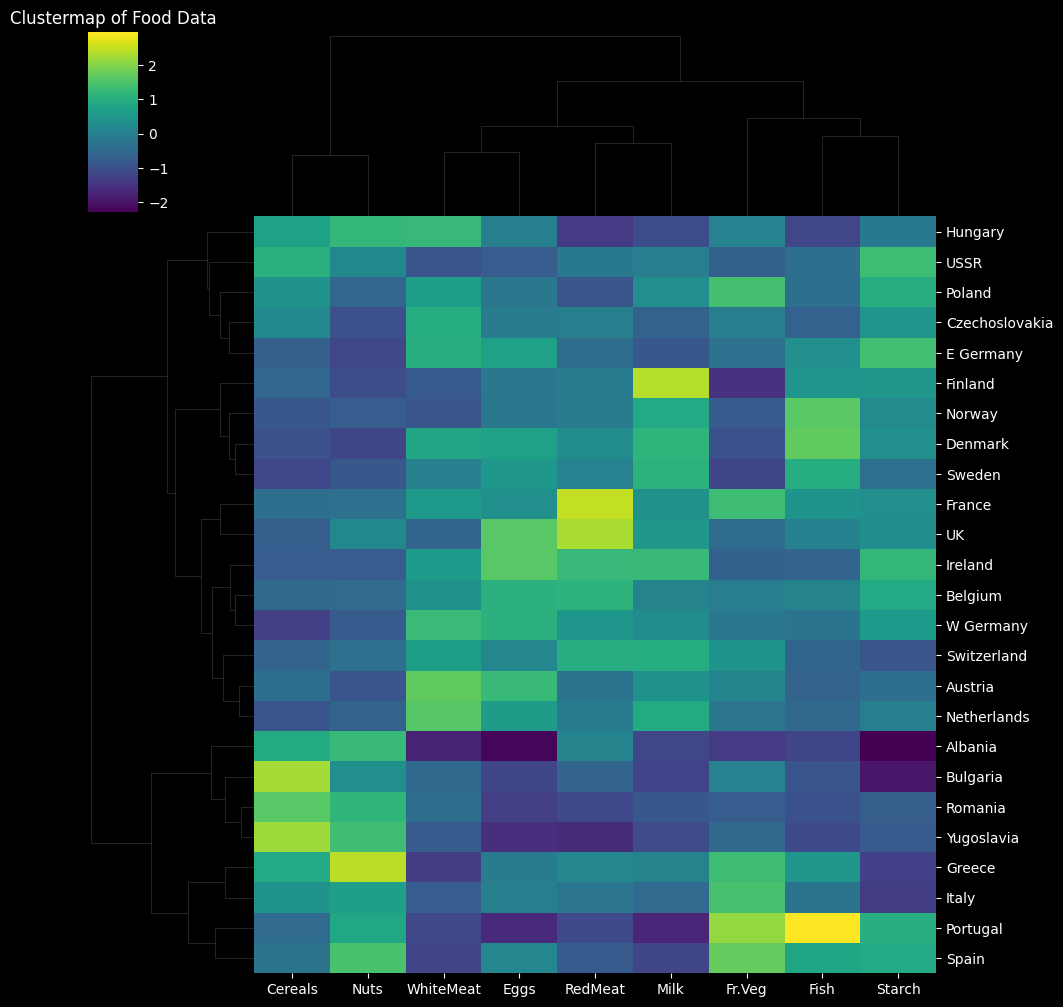

In [33]:
# Create a heatmap using seaborn.clustermap() for clustering of samples and variables.
sns.clustermap(food_scaled, method='ward', cmap='viridis',
               yticklabels=food.index,
               xticklabels=food.columns) # cmap color map 
plt.title('Clustermap of Food Data')
plt.show()  

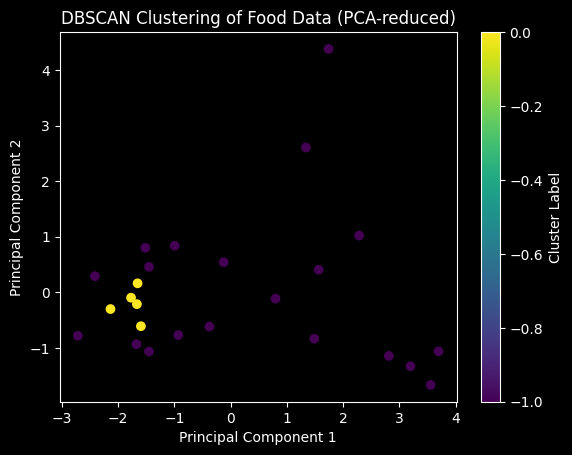

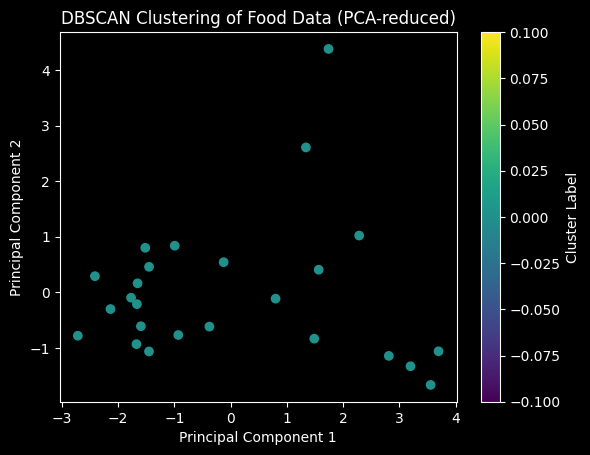

In [ ]:
# perform density-based clustering using DBSCAN from sklearn.cluster.
from sklearn.cluster import DBSCAN
# fit DBSCAN with eps=0.5 and min_samples=5
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(food_pca)
# visualize the clusters using matplotlib. pyplot. scatter from matplotlib. pyplot. 
plt.scatter(food_pca[:, 0], food_pca[:, 1], c=dbscan.labels_, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering of Food Data (PCA-reduced)')
plt.colorbar(label='Cluster Label')
plt.show()

# fit DBSCAN with eps=2 (according to the k-distance graph) and min_samples=  something smaller than 2x number of features (18)
dbscan = DBSCAN(eps=2, min_samples=2)
dbscan.fit(food_pca)
# visualize the clusters using matplotlib. pyplot. scatter from matplotlib. pyplot. 
plt.scatter(food_pca[:, 0], food_pca[:, 1], c=dbscan.labels_, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering of Food Data (PCA-reduced)')
plt.colorbar(label='Cluster Label')
plt.show()

# doesn't work well for this dataset, no good clusters found even when varying eps and min_samples.

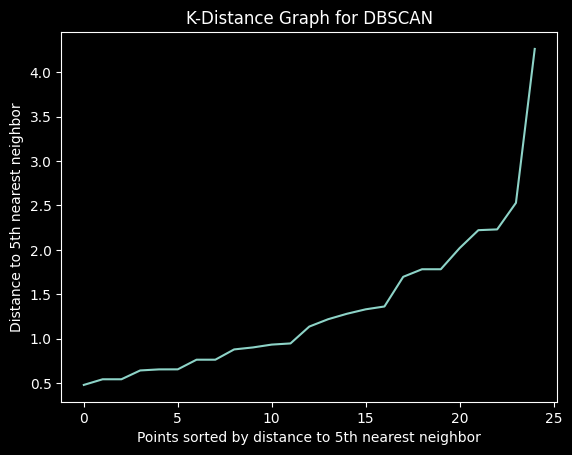

In [24]:
# define best value for epsilon by using a k-distance Graph and looking for the elbow point.
from sklearn.neighbors import NearestNeighbors
# compute the k-nearest neighbors for each point
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(food_pca)
distances, indices = neighbors_fit.kneighbors(food_pca)
# sort the distances to the 5th nearest neighbor
distances = np.sort(distances[:, 4])
# plot the k-distance graph
plt.plot(distances)
plt.xlabel('Points sorted by distance to 5th nearest neighbor')
plt.ylabel('Distance to 5th nearest neighbor')
plt.title('K-Distance Graph for DBSCAN')
plt.show()

Update Git repository

Run git add ., git commit -m "Clustering analysis", git push in the terminal